This notebook tests the ResNet-18 architecture on the CK+ dataset only.

The ResNet-18 model utilizes pre-trained weights, and the CK+ dataset is train throughout the networks layers.

Model Parameters:
* optimizer = Adam [lr = 0.001, weight_decay=0.01]
* loss function = Cross Entropy Loss (weights = None)

Early stopping is applied to combat overfitting. 

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from PIL import Image
from myDataset import *
from ArchitectureMethods import *
from MetricMethods import *

seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.cpu.manual_seed = seed
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [2]:
# Sets current directory as ws
print(os.getcwd())
os.chdir('..')
print(os.getcwd())
# Checks if device is available (GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

train_dataset = myDataset(directory = "DATASET/train", transform = train_transform)
val_dataset = myDataset(directory = "DATASET/validation", transform = val_transform)
test_dataset = myDataset(directory = "DATASET/test", transform = test_transform)

print(f'Train set length: '+ str(len(train_dataset)))
print(f'Test set length: '+ str(len(val_dataset)))
print(f'Validation set length: '+ str(len(test_dataset)))

train_loader = DataLoader(train_dataset, batch_size = 16, shuffle = True, num_workers = 8)
val_loader = DataLoader(val_dataset, batch_size = 16, shuffle = False, num_workers = 8)
test_loader = DataLoader(test_dataset, batch_size = 16, shuffle = False, num_workers = 8)



/user/HS401/ob00564/Documents/COM3001/CK+/Transfer Learning
/user/HS401/ob00564/Documents/COM3001/CK+
cuda
Train set length: 720
Test set length: 89
Validation set length: 93


In [3]:
sorted_emotion_counts = train_dataset.getNoImagesInClass()
print(sorted_emotion_counts)
sorted_emotion_counts = val_dataset.getNoImagesInClass()
print(sorted_emotion_counts)
sorted_emotion_counts = test_dataset.getNoImagesInClass()
print(sorted_emotion_counts)

{'0': 36, '1': 47, '2': 20, '3': 55, '4': 22, '5': 66, '6': 474}
{'0': 4, '1': 6, '2': 2, '3': 7, '4': 3, '5': 8, '6': 59}
{'0': 5, '1': 6, '2': 3, '3': 7, '4': 3, '5': 9, '6': 60}


In [4]:
# @title Importing ResNet34 model, using DEFAULT weights
import torchvision.models as models
emotionTotal = 7
myModel = models.resnet18(weights = 'DEFAULT')
print(myModel)
myModel

# Freeze all layers
for param in myModel.parameters():
    param.requires_grad = False

for param in myModel.fc.parameters():
    param.requires_grad = True

for param in myModel.layer4.parameters():
    param.requires_grad = True
    
myModel.fc = nn.Sequential(nn.Linear(myModel.fc.in_features,emotionTotal))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
myModel.to(device)
print(device)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [6]:
import copy
# @title Training Loop
from tqdm import tqdm
# Loss function 
criterion = nn.CrossEntropyLoss()

# Optimizer
# optimizer = optim.SGD(myModel.parameters(), lr = 0.0001, momentum=0.9, weight_decay= 0.001)
optimizer = optim.Adam(myModel.parameters(), lr = 0.00001, weight_decay=0.01)

train_losses, val_losses, train_accuracy, val_accuracy = train(myModel, device, train_loader, val_loader, optimizer, None, 100, criterion, "CK+/Transfer Learning/CK+ ResNet18.pth")
y_true, y_pred, y_score = test(myModel, device, criterion, test_loader, 'Test')

100%|██████████| 45/45 [00:01<00:00, 35.59it/s]


Epoch 1/100, Training Loss: 2.3990, Validation Loss: 2.1923
Epoch 1/100, Training Acc: 8.75, Validation Accuracy: 10.416666666666668


100%|██████████| 45/45 [00:00<00:00, 53.85it/s]


Epoch 2/100, Training Loss: 2.0252, Validation Loss: 1.9148
Epoch 2/100, Training Acc: 20.694444444444443, Validation Accuracy: 22.916666666666664


100%|██████████| 45/45 [00:00<00:00, 57.33it/s]


...

Epoch 40/100, Training Loss: 0.0774, Validation Loss: 0.3145
Epoch 40/100, Training Acc: 99.16666666666667, Validation Accuracy: 89.81481481481482


100%|██████████| 45/45 [00:00<00:00, 53.80it/s]


Epoch 41/100, Training Loss: 0.0732, Validation Loss: 0.3083
Epoch 41/100, Training Acc: 99.86111111111111, Validation Accuracy: 90.8564814814815


100%|██████████| 45/45 [00:00<00:00, 53.43it/s]


Model saved successfully!
Test Loss: 0.2914, Test Accuracy: 91.40%


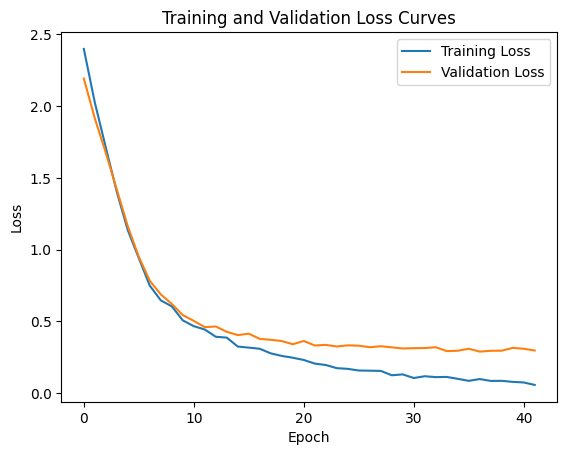

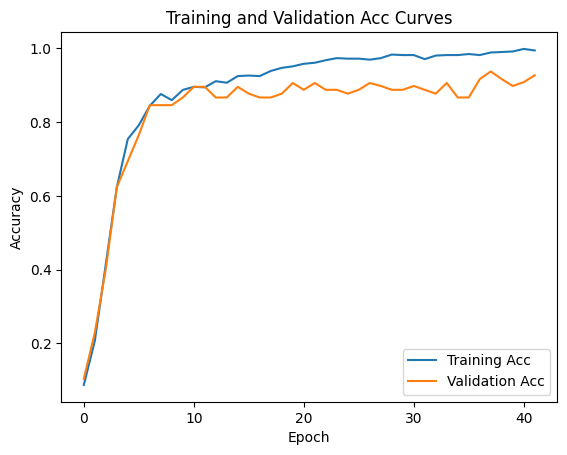

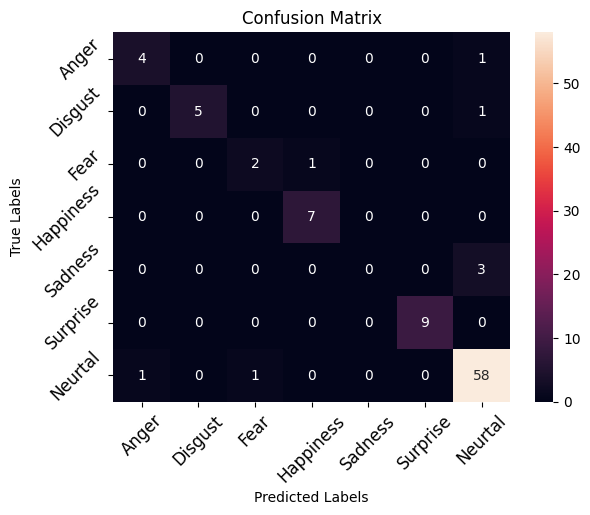

              precision    recall  f1-score   support

       Anger     0.8000    0.8000    0.8000         5
     Disgust     1.0000    0.8333    0.9091         6
        Fear     0.6667    0.6667    0.6667         3
   Happiness     0.8750    1.0000    0.9333         7
     Sadness     0.0000    0.0000    0.0000         3
    Surprise     1.0000    1.0000    1.0000         9
     Neurtal     0.9206    0.9667    0.9431        60

    accuracy                         0.9140        93
   macro avg     0.7518    0.7524    0.7503        93
weighted avg     0.8856    0.9140    0.8986        93



/user/HS401/ob00564/Documents/COM3001/myenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/user/HS401/ob00564/Documents/COM3001/myenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/user/HS401/ob00564/Documents/COM3001/myenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

: 

In [7]:
lossPlot(train_losses, val_losses)
accuracyPlot(train_accuracy, val_accuracy)
confusionMatrixPlot(y_true, y_pred)